
<h1 style="text-align: center;">CIÊNCIA DE DADOS</h1>
<h1 style="text-align: center;">Roteiro de Atividade Prática</h1>
<br>
<br>

Nome: ______________________________________________________________________________________      

Turma: ______________


**Componente:** Inteligência Artificial 
<br>
**Unidade Curricular:** Redes Neurais
<br>
**Tema da Semana:** Overfitting e Regularização
<br>


# Aula 3: Exercícios de fixação

## Tarefa

- Se as bibliotecas não tiverem instaladas, instale-as.

- Acompanhe as instruções.

- Preencha o código onde está #TO DO

- Execute o código.

- Responda as perguntas e conclua a atividade


### Instalação das dependência do tensorflow

In [1]:
#!pip install --upgrade pip setuptools wheel

In [2]:
#!pip install tensorflow

In [3]:
#!conda install anaconda::tensorflow

In [4]:
#!pip install scikit-learn numpy pandas matplotlib

### Imports de dependências

In [19]:
import random
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import Precision, Recall
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow.keras import backend as K

In [6]:
# Limpar o estado do backend do TensorFlow
K.clear_session()

### Configurações

In [7]:
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

### Leitura dos dados

In [8]:
penguins = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv')

# Remover valores nulos
penguins.dropna(inplace=True)

In [9]:
X = penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].values
y = penguins['species'].values

### Ajuste de classes para inteiros

In [10]:
encoder = OneHotEncoder(sparse=False)
y = encoder.fit_transform(y.reshape(-1, 1))

/home/fabiojanes/.local/lib/python3.8/site-packages/sklearn/preprocessing/_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


### Normalização de dados numéricos

In [11]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

### Divisão do conjunto de dados em treino e teste

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

### Criação o modelo


In [13]:
def create_model(regularization=None, dropout=False):
    K.clear_session()
    model = Sequential()
    model.add(Input(shape=(4,)))

    if regularization == 'l1':
        model.add(Dense(16, activation='relu', kernel_regularizer=regularizers.l1(0.3)))
        model.add(Dense(16, activation='relu', kernel_regularizer=regularizers.l1(0.3)))
    elif regularization == 'l2':
        model.add(Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.8)))
        model.add(Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.8)))
    elif dropout:
        model.add(Dense(16, activation='relu'))
        model.add(Dropout(0.8))
        model.add(Dense(16, activation='relu'))
        model.add(Dropout(0.8))
    else:
        model.add(Dense(16, activation='relu'))
        model.add(Dense(16, activation='relu'))
    
    model.add(Dense(3, activation='softmax'))
    
    model.compile(optimizer='adam', 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy', Precision(), Recall()])
    return model

### Treinamento dos modelos

In [14]:
print("\nTreinando com L1 Regularization")
model_l1 = create_model(regularization='l1')
early_stopping_l1 = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
history_l1 = model_l1.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, callbacks=[early_stopping_l1], verbose=0)

K.clear_session()

2024-09-25 02:15:02.571854: W tensorflow/stream_executor/platform/default/dso_loader.cc:59] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2024-09-25 02:15:02.571873: W tensorflow/stream_executor/cuda/cuda_driver.cc:312] failed call to cuInit: UNKNOWN ERROR (303)
2024-09-25 02:15:02.571886: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (fabiojanes-ThinkPad-E14): /proc/driver/nvidia/version does not exist
2024-09-25 02:15:02.572054: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN)to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-09-25 02:15:02.594553: I tensorflow/core/platform/profile_utils/cpu_utils.cc:104] CPU Frequency


Treinando com L1 Regularization


In [15]:
print("\nTreinando com L2 Regularization")
model_l2 = create_model(regularization='l2')
early_stopping_l2 = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
history_l2 = model_l2.fit(X_train, y_train, epochs=25, batch_size=32, validation_split=0.2, callbacks=[early_stopping_l2], verbose=0)

K.clear_session()


Treinando com L2 Regularization


In [16]:
print("\nTreinando com Dropout")
model_dropout = create_model(dropout=True)
early_stopping_dropout = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
history_dropout = model_dropout.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, callbacks=[early_stopping_dropout], verbose=0)
K.clear_session()


Treinando com Dropout


In [17]:
def plot_training_history(history, early_stopping, title):
    best_epoch = early_stopping.stopped_epoch - early_stopping.patience + 1
    
    epochs = range(1, len(history.history['loss']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['loss'], label='Perda - Treinamento')
    plt.plot(epochs, history.history['val_loss'], label='Perda - Validação')
    plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Melhor Época (Época {best_epoch})')
    plt.title(f'Curva de Perda - {title}')
    plt.xlabel('Épocas')
    plt.ylabel('Perda')
    plt.legend()
    plt.xticks(epochs)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['accuracy'], label='Acurácia - Treinamento')
    plt.plot(epochs, history.history['val_accuracy'], label='Acurácia - Validação')
    plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Melhor Época (Época {best_epoch})')
    plt.title(f'Curva de Acurácia - {title}')
    plt.xlabel('Épocas')
    plt.ylabel('Acurácia')
    plt.legend()
    plt.xticks(epochs)
    
    # Mostrar o gráfico
    plt.show()

    return best_epoch

def print_best_epoch_metrics(history, best_epoch):
    best_val_loss = history.history['val_loss'][best_epoch-1]
    best_val_accuracy = history.history['val_accuracy'][best_epoch-1]
    best_val_precision = history.history['val_precision'][best_epoch-1]
    best_val_recall = history.history['val_recall'][best_epoch-1]

    print(f"\nMelhor Época: {best_epoch}")
    print(f"val_loss: {best_val_loss:.4f}")
    print(f"val_accuracy: {best_val_accuracy:.4f}")
    print(f"val_precision: {best_val_precision:.4f}")
    print(f"val_recall: {best_val_recall:.4f}")



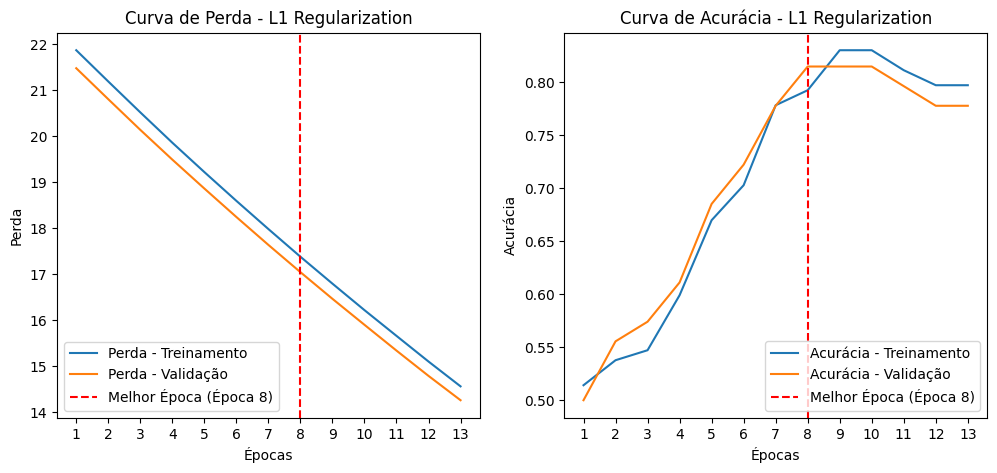


Melhor Época: 8
val_loss: 17.0422
val_accuracy: 0.8148
val_precision: 1.0000
val_recall: 0.2407


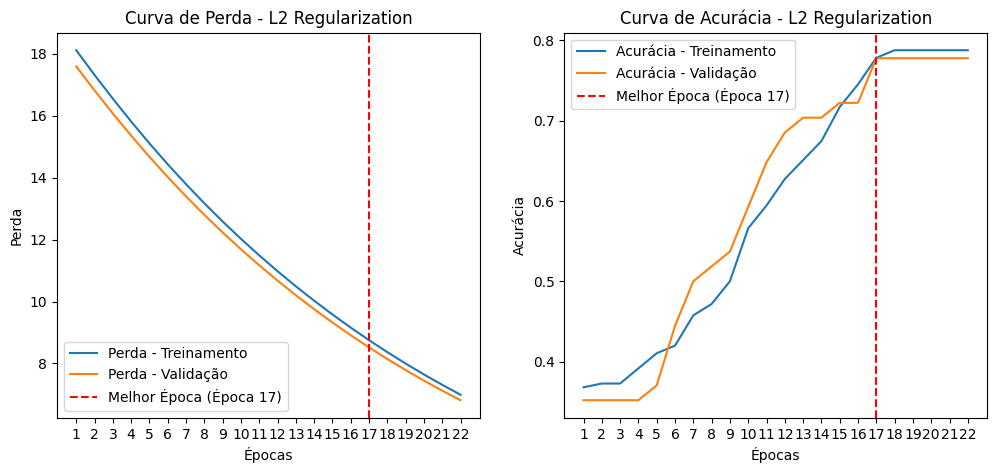


Melhor Época: 17
val_loss: 8.5188
val_accuracy: 0.7778
val_precision: 0.5000
val_recall: 0.0556


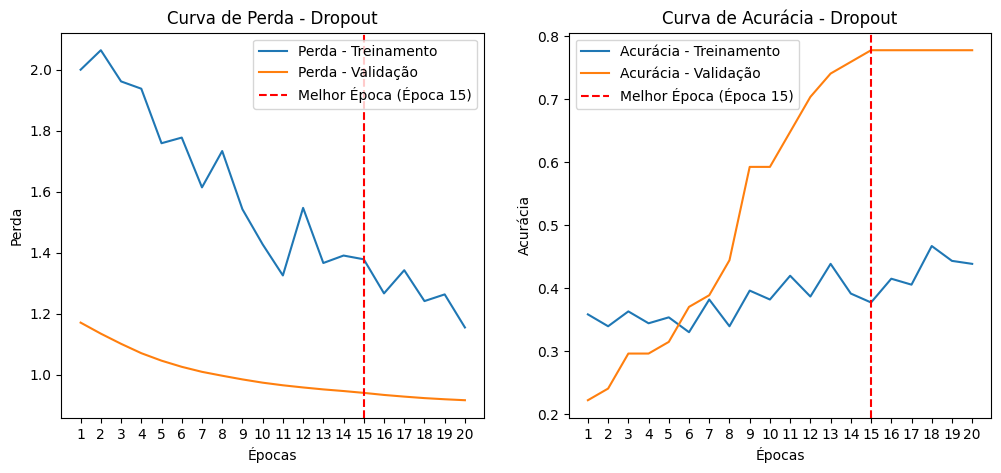


Melhor Época: 15
val_loss: 0.9402
val_accuracy: 0.7778
val_precision: 1.0000
val_recall: 0.1296


In [18]:
# Modelo com L1 Regularization
best_epoch_l1 = plot_training_history(history_l1, early_stopping_l1, title="L1 Regularization")
print_best_epoch_metrics(history_l1, best_epoch_l1)

# Modelo com L2 Regularization
best_epoch_l2 = plot_training_history(history_l2, early_stopping_l2, title="L2 Regularization")
print_best_epoch_metrics(history_l2, best_epoch_l2)

# Modelo com Dropout
best_epoch_dropout = plot_training_history(history_dropout, early_stopping_dropout, title="Dropout")
print_best_epoch_metrics(history_dropout, best_epoch_dropout)

#### Selecione o melhor modelo de acordo com as métricas perda (loss) e acurácia

In [25]:
#TO DO
best_model = model_l1
#best_model = model_l2
#best_model = model_dropout

# Avaliação o modelo

In [27]:
loss, accuracy, precision, recall = best_model.evaluate(X_test, y_test)
print(f'Test accuracy: {accuracy:.4f}')
print(f'Test precision: {precision:.4f}')
print(f'Test recall: {recall:.4f}')
print(f'Test loss: {loss:.4f}')

3/3 [==============================] - 0s 1ms/step - loss: 17.0244 - accuracy: 0.8209 - precision: 1.0000 - recall: 0.2090
Test accuracy: 0.8209
Test precision: 1.0000
Test recall: 0.2090
Test loss: 17.0244


### Perguntas e Conclusão

##### Qual foi o método de regularização com melhor perda (loss) e acurácia?
##### Quais os valores das métricas loss, acurácia, precisão e recall utilizando o Dataset de teste?